# ASL dataset loading test

Author: TAM Ka Ho (1155175983)

References: 
* Contrastive Learning: 
  * [Source Publication](https://www.researchgate.net/publication/347038642_Fisher_Discriminant_Triplet_and_Contrastive_Losses_for_Training_Siamese_Networks) 
  * [tensorflow: siamese network](https://www.kaggle.com/code/tatianakushniruk/face-recognition-with-siamese-network/notebook)
* Dataset:
  * [ASL Dataset by LEXSET@Kaggle](https://www.kaggle.com/datasets/lexset/synthetic-asl-alphabet)
  
We would first attempt to load the ASL dataset.

In Kaggle, add the following dataset:
https://www.kaggle.com/datasets/lexset/synthetic-asl-alphabet/data

If you are using VS Code, execute in the command line
```bash
kaggle datasets download -d lexset/synthetic-asl-alphabet
mkdir "kaggle/input/synthetic-asl-alphabet"
tar -xf synthetic-asl-alphabet.zip -C kaggle/input/synthetic-asl-alphabet
```
Search for installation guides for the kaggle command if it is not working.

## Import Libraries

In [1]:
import os
import zipfile
import shutil

import random
import math
from tqdm import tqdm

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Flatten, Dense,\
                                    Dropout, BatchNormalization, Input
from tensorflow.keras.metrics import Mean, CosineSimilarity
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB7, preprocess_input

## Settings and Configs

### Dataset-Related

In [2]:
USING_KAGGLE = False
INPUT_FOLDER = '/kaggle/input' if USING_KAGGLE else 'kaggle/input'

In [3]:
import os
if not USING_KAGGLE:
    updir = os.path.dirname
    BASE_PATH = updir(updir(updir(__vsc_ipynb_file__)))
    INPUT_FOLDER = os.path.normpath(os.path.join(BASE_PATH, INPUT_FOLDER))
    print(BASE_PATH, INPUT_FOLDER)

d:\kht3327\_Projects\Major FYP\proj d:\kht3327\_Projects\Major FYP\proj\kaggle\input


In [4]:
TRAIN_DATA_PATH = f'{INPUT_FOLDER}/synthetic-asl-alphabet/Train_Alphabet'
TEST_DATA_PATH = f'{INPUT_FOLDER}/synthetic-asl-alphabet/Test_Alphabet'

## Dataset Retrieval

In [5]:
def explore_folder(folder_path):
    print(f'Exploring {os.path.basename(folder_path)}')
    image_shapes = []
    num_images = 0
    num_people = 0
    for folder_name in tqdm(os.listdir(folder_path),'File Progress'):
        subfolder_path = os.path.join(folder_path, folder_name)
        for image_name in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, image_name)
            image = cv2.imread(image_path)
            image_shapes.append(image.shape)
            num_images += 1
        num_people +=1
    print(f'Unique image shapes in: {set(image_shapes)}')
    print(f"Total number of images: {num_images}")
    print(f"Total number of people: {num_people}")
    return image_shapes, num_images, num_people

In [6]:
explore_folder(TRAIN_DATA_PATH);

Exploring Train_Alphabet


File Progress: 100%|██████████| 27/27 [03:53<00:00,  8.64s/it]

Unique image shapes in: {(512, 513, 3)}
Total number of images: 24300
Total number of people: 27


In [7]:
explore_folder(TEST_DATA_PATH);

Exploring Test_Alphabet


File Progress: 100%|██████████| 27/27 [00:15<00:00,  1.69it/s]

Unique image shapes in: {(512, 513, 3)}
Total number of images: 2700
Total number of people: 27


This dataset only contains 27 classes and 24300 images, averaging to 900 images per class.

### Visualizing Sample Images

In [8]:
def visualize_sample_images(folder_path):
    num_images = len(os.listdir(folder_path))
    num_rows = min((num_images + 4) // 5, 2)
    num_cols = min(num_images, 5)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 3 * num_rows))

    for i, image_name in enumerate(os.listdir(folder_path)):
        if i >= 2 * num_cols:
             break
        image_path = os.path.join(folder_path, image_name)
        sample_image = cv2.imread(image_path)
        sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

        row = i // num_cols
        col = i % num_cols

        if num_rows == 1:
              ax = axes[col]
        else:
            ax = axes[row, col]

        ax.imshow(sample_image)
        ax.axis('off')

    for ax in axes.flat[num_images:]:
          ax.remove()

    plt.suptitle(f'Person ID: {os.path.basename(folder_path)}')
    plt.tight_layout()
    plt.show()

Viewing random sample image:

Samples from Train_Alphabet


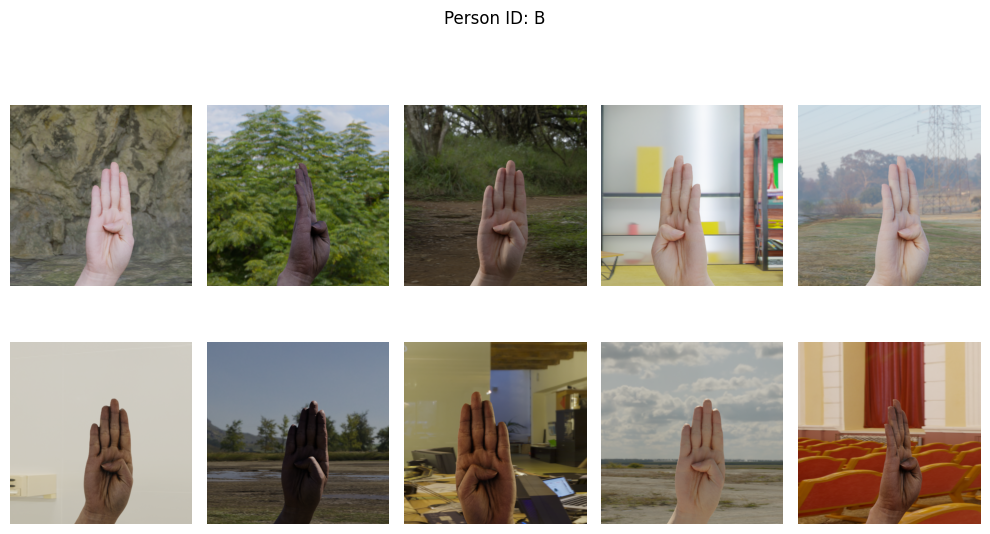

In [9]:
class_id = random.choice(os.listdir(TRAIN_DATA_PATH))
folder_path = os.path.join(TRAIN_DATA_PATH, class_id)
print(f'Samples from {os.path.basename(TRAIN_DATA_PATH)}')
visualize_sample_images(folder_path)

Samples from Test_Alphabet


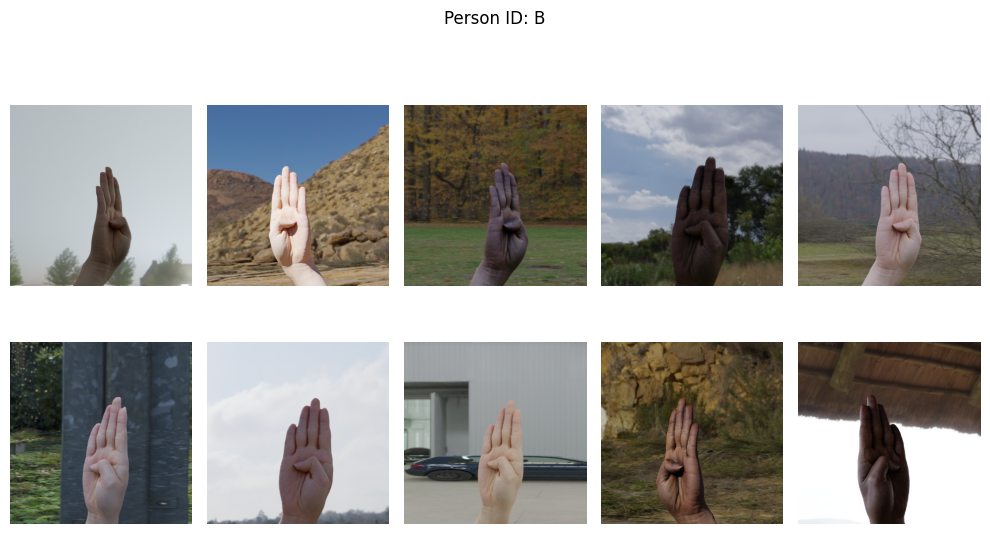

In [10]:
print(f'Samples from {os.path.basename(TEST_DATA_PATH)}')
if class_id in os.listdir(TEST_DATA_PATH):
    folder_path = os.path.join(TEST_DATA_PATH, class_id)  
    visualize_sample_images(folder_path)
else:
    print(f'There is no person {class_id} in this folder')

### Generating Triplets for Contrastive Learning

In [11]:
def dataset(folder_paths, max_triplets=80):
    # anchor_images = []
    # positive_images = []
    # negative_images = []

    while True:
        images_set = []

        for person_folder in folder_paths:
            images = [os.path.join(person_folder, img)
                    for img in os.listdir(person_folder)]
            num_images = len(images)

            if num_images < 2:
                continue

            random.shuffle(images)

            for _ in range(min(num_images-1, max_triplets)):
                anchor_image = random.choice(images)

                positive_image = random.choice([x for x in images
                                                if x != anchor_image])

                negative_folder = random.choice([x for x in folder_paths
                                                if x != person_folder])

                negative_image = random.choice([os.path.join(negative_folder, img)
                                                for img in os.listdir(negative_folder)])

                images_set.append((anchor_image, positive_image, negative_image))
                # anchor_images.append(anchor_image)
                # positive_images.append(positive_image)
                # negative_images.append(negative_image)

        yield images_set

In [12]:
train_folders = [os.path.join(TRAIN_DATA_PATH, folder_name)
                  for folder_name in os.listdir(TRAIN_DATA_PATH)]
val_folders = [os.path.join(TEST_DATA_PATH, folder_name)
                  for folder_name in os.listdir(TEST_DATA_PATH)]

train_set = dataset(train_folders)
val_set = dataset(val_folders)

### Splitting Triplets

In [13]:
# def split_triplets(anchors,
#                    positives,
#                    negatives,
#                    validation_split=0.2):

#     triplets = list(zip(anchors, positives, negatives))

#     train_triplets, val_triplets = train_test_split(triplets,
#                                                     test_size=validation_split,
#                                                     random_state=42)

#     return train_triplets, val_triplets

In [14]:
# train_set, val_set = split_triplets(anchors, positives, negatives)
len(next(train_set)), len(next(val_set))

(2160, 2160)

### Loading and Preprocessing Images

Resizing to the same size and transform to numpy format compatible with the model, that is, (B, C, W, H).

In [15]:
def load_and_preprocess_image(image_path, expand_dims=False):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (128, 128))
    if expand_dims:
        image = np.expand_dims(image, axis=0)
    return image

### Batch Generator

In [16]:
def batch_generator(data, batch_size=32, augment=True):
    total_triplets = len(data)
    random_indices = list(range(total_triplets))
    random.shuffle(random_indices)
    
    datagen = ImageDataGenerator(
        rotation_range=10,  
        width_shift_range=0.05, 
        height_shift_range=0.05,   
        horizontal_flip=True,
        zoom_range=0.2
    )
    
    for i in range(0, total_triplets, batch_size):
        batch_indices = random_indices[i:i + batch_size]
        batch_triplets = [data[j] for j in batch_indices]

        anchor_batch = []
        positive_batch = []
        negative_batch = []

        for triplet in batch_triplets:
            anchor, positive, negative = triplet
            
            anchor_image = load_and_preprocess_image(anchor)
            positive_image = load_and_preprocess_image(positive)
            negative_image = load_and_preprocess_image(negative)
                
            if augment:
                anchor_image = datagen.random_transform(anchor_image)
                positive_image = datagen.random_transform(positive_image)
                negative_image = datagen.random_transform(negative_image)

            anchor_batch.append(anchor_image)
            positive_batch.append(positive_image)
            negative_batch.append(negative_image)

        yield [np.array(anchor_batch),
               np.array(positive_batch),
               np.array(negative_batch)]

### Visualizing Triplets

In [17]:
def visualize_triplets(triplets):
    anchor_batch, positive_batch, negative_batch = triplets

    for i in range(len(anchor_batch)):
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.title("Anchor")
        plt.imshow(anchor_batch[i])
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Positive")
        plt.imshow(positive_batch[i])
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Negative")
        plt.imshow(negative_batch[i])
        plt.axis('off')

        plt.show()

Visuale a random batch:

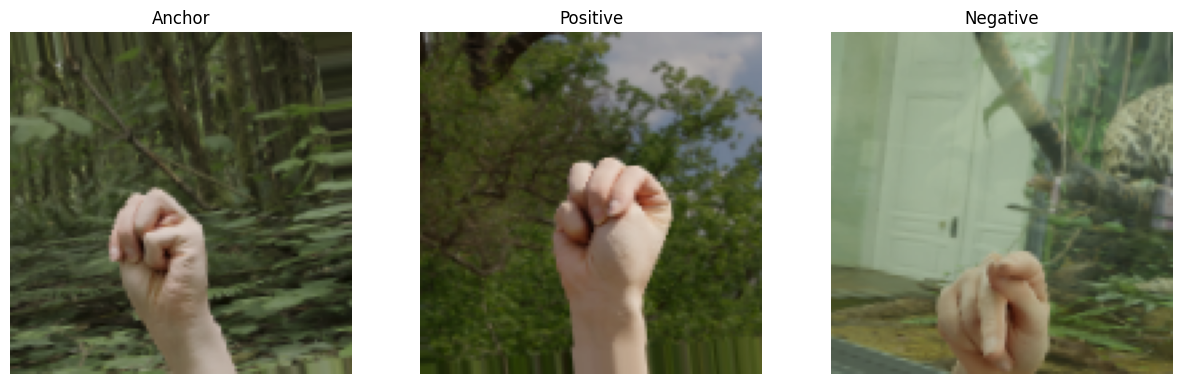

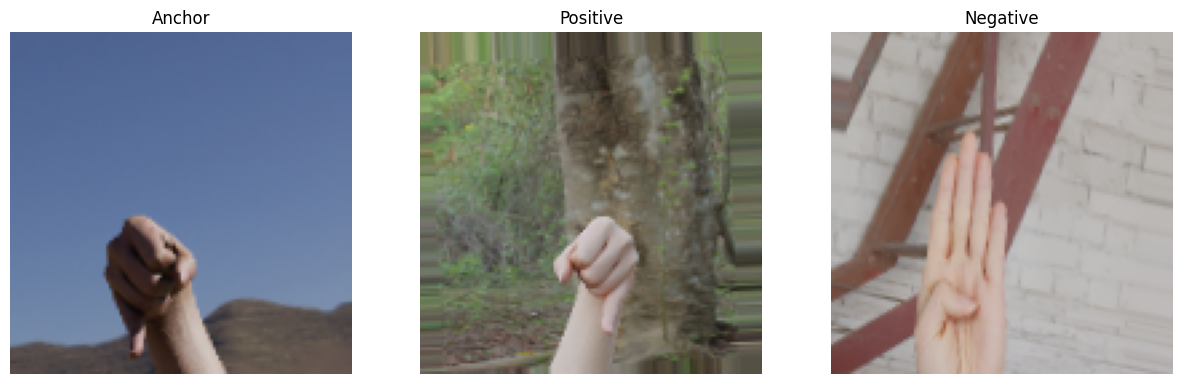

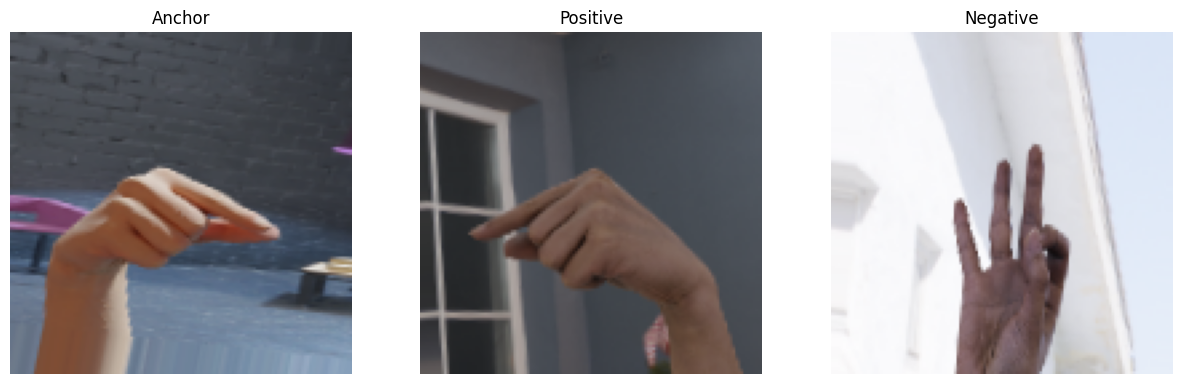

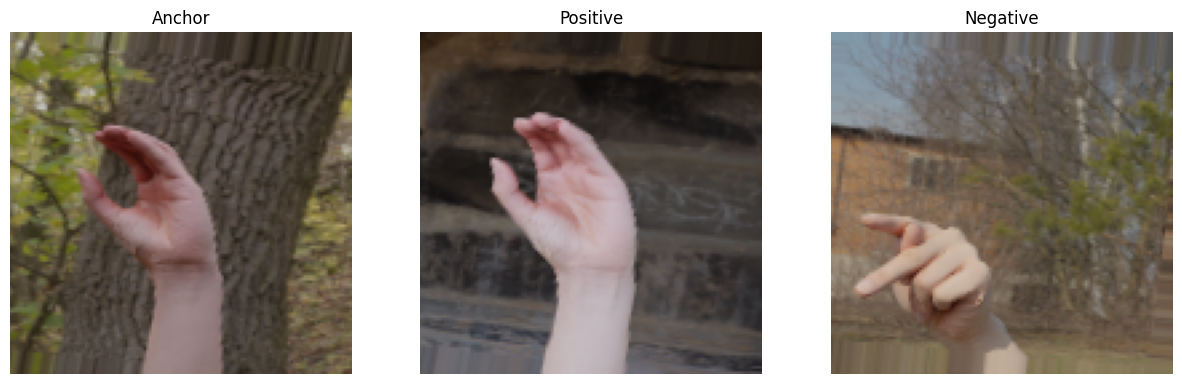

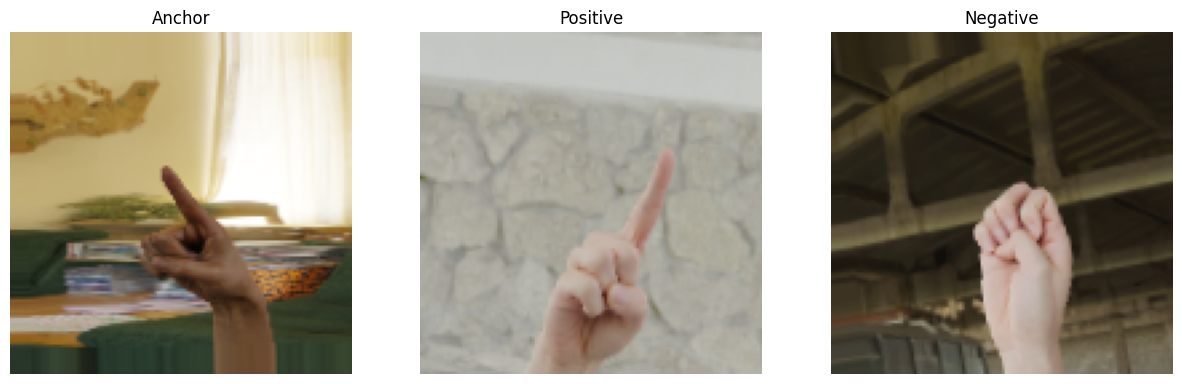

In [18]:
example_triplets = [next(batch_generator(next(train_set), 5))]
visualize_triplets(example_triplets[0])

## Siamese Network

### Embedding Model

Uses **EfficientNetB7** as the backbone.

In [19]:
def get_embedding(input_shape, num_layers_to_unfreeze=25):
    base_model = EfficientNetB7(weights='imagenet',
                                input_shape=input_shape,
                                include_top=False,
                                pooling='avg')

    for i in range(len(base_model.layers)-num_layers_to_unfreeze):
        base_model.layers[i].trainable = False

    embedding = tf.keras.models.Sequential([
        base_model,
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dense(128)
    ], name='Embedding')

    return embedding

In [20]:
input_shape = (128, 128, 3)

embedding = get_embedding(input_shape)
embedding.summary()

Model: "Embedding"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb7 (Functional)  (None, 2560)             64097687  
                                                                 
 flatten (Flatten)           (None, 2560)              0         
                                                                 
 dense (Dense)               (None, 512)               1311232   
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                         

### Siamese Network Architecture

Basically we compute the distance layer for the latent vectors of the triplet after passing them through the embedding network individually.

In [21]:
# @tf.keras.saving.register_keras_serializable() # tf 2.12+
@tf.keras.utils.register_keras_serializable() # tf 2.10
class DistanceLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = tf.reduce_sum(tf.square(anchor - positive), -1)
        an_distance = tf.reduce_sum(tf.square(anchor - negative), -1)
        return ap_distance, an_distance

In [22]:
anchor_input = Input(name='anchor', shape=input_shape)
positive_input = Input(name='positive', shape=input_shape)
negative_input = Input(name='negative', shape=input_shape)

distances = DistanceLayer()(
    embedding(preprocess_input(anchor_input)),
    embedding(preprocess_input(positive_input)),
    embedding(preprocess_input(negative_input))
)

siamese_net = Model(
    inputs=[anchor_input,
            positive_input,
            negative_input],
    outputs=distances
)

In [23]:
plot_model(siamese_net, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [24]:
siamese_net.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 anchor (InputLayer)            [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 positive (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 negative (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                            

### Training and Evaluation of Network (Encapsulated)

In [25]:
# @tf.keras.saving.register_keras_serializable() # tf 2.12+
@tf.keras.utils.register_keras_serializable() # tf 2.10
class SiameseModel(Model):
    def __init__(self, siamese_net, margin=0.5):
        super().__init__()
        self.siamese_net = siamese_net
        self.margin = margin
        self.loss_tracker = Mean(name='loss')
        self.accuracy_tracker = Mean(name='accuracy')

    def call(self, inputs):
        return self.siamese_net(inputs)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        gradients = tape.gradient(loss, self.siamese_net.trainable_weights)

        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_net.trainable_weights)
        )

        self.loss_tracker.update_state(loss)

        accuracy = self._compute_accuracy(data)
        self.accuracy_tracker.update_state(accuracy)

        return {'loss': self.loss_tracker.result(),
                'accuracy': self.accuracy_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        self.loss_tracker.update_state(loss)

        accuracy = self._compute_accuracy(data)
        self.accuracy_tracker.update_state(accuracy)

        return {'loss': self.loss_tracker.result(),
                'accuracy': self.accuracy_tracker.result()}

    def _compute_loss(self, data):
        ap_distance, an_distance = self.siamese_net(data)

        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, .0)
        return loss

    def _compute_accuracy(self, data):
        ap_distance, an_distance = self.siamese_net(data)
        accuracy = tf.reduce_mean(tf.cast(ap_distance < an_distance,
                                          tf.float32))
        return accuracy

    @property
    def metrics(self):
        return [self.loss_tracker, self.accuracy_tracker]

    # def get_config(self):
    #     base_config = super().get_config()
    #     config = {
    #         'siamese_net': tf.keras.saving.serialize_keras_object(self.siamese_net),
    #         'margin': tf.keras.saving.serialize_keras_object(self.margin),
    #         'loss_tracker': tf.keras.saving.serialize_keras_object(self.loss_tracker),
    #         'accuracy_tracker': tf.keras.saving.serialize_keras_object(self.accuracy_tracker),
    #     }
    #     return {**base_config, **config}

    # @classmethod
    # def from_config(cls, config):
    #     config['siamese_net'] = tf.keras.saving.deserialize_keras_object(config.pop('siamese_net'))
    #     config['margin'] = tf.keras.saving.deserialize_keras_object(config.pop('margin'))
    #     config['loss_tracker'] = tf.keras.saving.deserialize_keras_object(config.pop('loss_tracker'))
    #     config['accuracy_tracker'] = tf.keras.saving.deserialize_keras_object(config.pop('accuracy_tracker'))
    #     return cls(**config)
    
    def get_config(self):
        base_config = super().get_config()
        config = {
            'siamese_net': tf.keras.utils.serialize_keras_object(self.siamese_net),
            'margin': self.margin,
            'loss_tracker': tf.keras.utils.serialize_keras_object(self.loss_tracker),
            'accuracy_tracker': tf.keras.utils.serialize_keras_object(self.accuracy_tracker),
        }
        return {**base_config, **config}

    @classmethod
    def from_config(cls, config):
        siamese_net = tf.keras.utils.deserialize_keras_object(config.pop('siamese_net'))
        margin = config.pop('margin')
        loss_tracker = tf.keras.utils.deserialize_keras_object(config.pop('loss_tracker'))
        accuracy_tracker = tf.keras.utils.deserialize_keras_object(config.pop('accuracy_tracker'))
        
        instance = cls(siamese_net=siamese_net, margin=margin)
        instance.loss_tracker = loss_tracker
        instance.accuracy_tracker = accuracy_tracker
        return instance

## Training

In [26]:
def train_model(model,
                train_set,
                epochs,
                batch_size,
                val_set,
                patience,
                delta=0.0001):

    best_val_accuracy = 0
    best_val_loss = float('inf')
    temp_patience = patience
    history = {
        'loss': [],
        'val_loss': [],
        'accuracy': [],
        'val_accuracy': []
    }

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        train_loss = 0.
        train_accuracy = 0.
        val_loss = 0.
        val_accuracy = 0.

        train_data = next(train_set)
        val_data = next(val_set)

        train_steps_per_epoch = math.ceil(len(train_data) / batch_size)
        val_steps_per_epoch = math.ceil(len(val_data) / batch_size)

        with tqdm(total=train_steps_per_epoch, desc='Training') as pbar:
            for batch in batch_generator(train_data, batch_size=batch_size):
                loss, accuracy = model.train_on_batch(batch)
                train_loss += loss
                train_accuracy += accuracy

                pbar.update()
                pbar.set_postfix({'Loss': loss, 'Accuracy': accuracy})

        with tqdm(total=val_steps_per_epoch, desc='Validation') as pbar:
            for batch in batch_generator(val_data, batch_size=batch_size):
                loss, accuracy = model.test_on_batch(batch)
                val_loss += loss
                val_accuracy += accuracy

                pbar.update()
                pbar.set_postfix({'Loss': loss, 'Accuracy': accuracy})

        train_loss /= train_steps_per_epoch
        train_accuracy /= train_steps_per_epoch
        val_loss /= val_steps_per_epoch
        val_accuracy /= val_steps_per_epoch

        history['loss'].append(train_loss)
        history['accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)

        print(f'\nTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}\n')

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            model.layers[0].layers[3].save_weights('best_model.weights.h5')

        if val_loss - best_val_loss > delta:
            temp_patience -= 1
            if temp_patience == 0:
                print('Early stopping: Validation loss did not improve.')
                break
        else:
            best_val_loss = val_loss
            temp_patience = patience

    return model, history

### Training Configs

In [27]:
EPOCHS = 200
BATCH_SIZE = 128
PATIENCE = 50

In [28]:
siamese_model = SiameseModel(siamese_net)
initial_lr = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_lr,
    decay_steps=10000,#0,
    decay_rate=0.96,
    staircase=True)

siamese_model.compile(optimizer=Adam(learning_rate=lr_schedule))

In [29]:
siamese_model, history = train_model(siamese_model,
                                     train_set=train_set,
                                     epochs=EPOCHS,
                                     batch_size=BATCH_SIZE,
                                     val_set=val_set,
                                     patience=PATIENCE)

Epoch 1/200


Validation: 100%|██████████| 17/17 [02:15<00:00,  7.96s/it, Loss=0.242, Accuracy=0.812]



Train Loss: 0.3466, Train Accuracy: 0.8791
Validation Loss: 0.2290, Validation Accuracy: 0.8074

Epoch 2/200


Validation: 100%|██████████| 17/17 [01:38<00:00,  5.80s/it, Loss=0.102, Accuracy=0.911]



Train Loss: 0.1832, Train Accuracy: 0.9087
Validation Loss: 0.1476, Validation Accuracy: 0.8780

Epoch 3/200


...


Train Loss: 0.0232, Train Accuracy: 0.9913
Validation Loss: 0.0450, Validation Accuracy: 0.9666

Epoch 199/200


Validation: 100%|██████████| 17/17 [01:32<00:00,  5.45s/it, Loss=0.0165, Accuracy=0.991]



Train Loss: 0.0305, Train Accuracy: 0.9906
Validation Loss: 0.0344, Validation Accuracy: 0.9760

Epoch 200/200


Validation: 100%|██████████| 17/17 [01:31<00:00,  5.39s/it, Loss=0.0507, Accuracy=0.955]


Train Loss: 0.0339, Train Accuracy: 0.9870
Validation Loss: 0.0422, Validation Accuracy: 0.9703



In [34]:
siamese_model, history2 = train_model(siamese_model,
                                     train_set=train_set,
                                     epochs=EPOCHS,
                                     batch_size=BATCH_SIZE,
                                     val_set=val_set,
                                     patience=PATIENCE)

Epoch 1/200


Validation: 100%|██████████| 17/17 [01:54<00:00,  6.73s/it, Loss=0.043, Accuracy=0.973] 



Train Loss: 0.0277, Train Accuracy: 0.9885
Validation Loss: 0.0389, Validation Accuracy: 0.9745

Epoch 2/200


Validation: 100%|██████████| 17/17 [01:34<00:00,  5.54s/it, Loss=0.037, Accuracy=0.964] 



Train Loss: 0.0317, Train Accuracy: 0.9893
Validation Loss: 0.0363, Validation Accuracy: 0.9735

Epoch 3/200


...


Train Loss: 0.0234, Train Accuracy: 0.9903
Validation Loss: 0.0383, Validation Accuracy: 0.9741

Epoch 57/200


Validation: 100%|██████████| 17/17 [01:32<00:00,  5.43s/it, Loss=0.051, Accuracy=0.964] 



Train Loss: 0.0250, Train Accuracy: 0.9875
Validation Loss: 0.0384, Validation Accuracy: 0.9703

Epoch 58/200


Validation: 100%|██████████| 17/17 [01:31<00:00,  5.36s/it, Loss=0.0419, Accuracy=0.982]


Train Loss: 0.0269, Train Accuracy: 0.9901
Validation Loss: 0.0355, Validation Accuracy: 0.9723

Early stopping: Validation loss did not improve.


## Evaluation

### Training Visualization

In [40]:
for k, v in history.items():
    print(k)
    history[k].extend(history2[k])

loss
val_loss
accuracy
val_accuracy


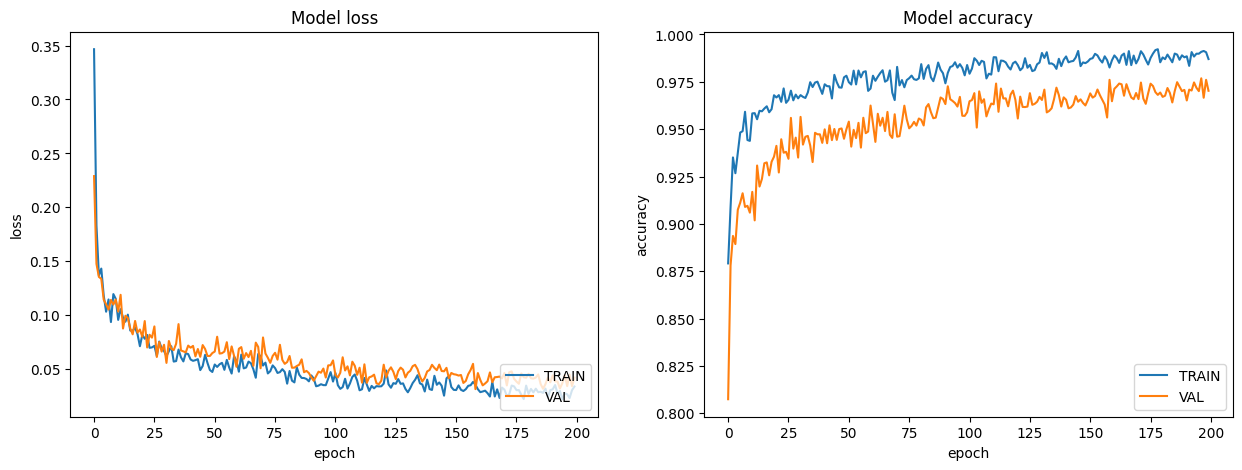

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['TRAIN', 'VAL'], loc='lower right')

plt.subplot(122)
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['TRAIN', 'VAL'], loc='lower right')

plt.show()

### Cosine Similiarity

In [ ]:
# Extract all images and labels from folders
all_embeddings = []
all_labels = []
image_data = []

for i, folder_path in tqdm(enumerate(train_folders), "Fetching"):
    label = os.path.basename(folder_path)  # Extract label from the folder name
    images = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    
    for image_path in images:
        image = load_and_preprocess_image(image_path)
        preprocessed_image = preprocess_input(image)
        image_data.append(preprocessed_image)
        all_labels.append(label)
    
    if i > 15:
        break
    
# Convert to a numpy array for batching
image_data = np.array(image_data)

# Process in batches
num_batches = int(np.ceil(len(image_data) / BATCH_SIZE))

for batch_idx in tqdm(range(num_batches), "Processing"):
    batch_images = image_data[batch_idx * BATCH_SIZE : (batch_idx + 1) * BATCH_SIZE]
    batch_embeddings = embedding(batch_images)  # Get embeddings for the batch
    
    for embedding_result in batch_embeddings:
        all_embeddings.append(embedding_result.numpy().flatten())

# Convert to numpy arrays
all_embeddings = np.array(all_embeddings)
all_labels = np.array(all_labels)

Fetching: 16it [01:38,  6.14s/it]
Processing: 100%|██████████| 120/120 [00:50<00:00,  2.37it/s]


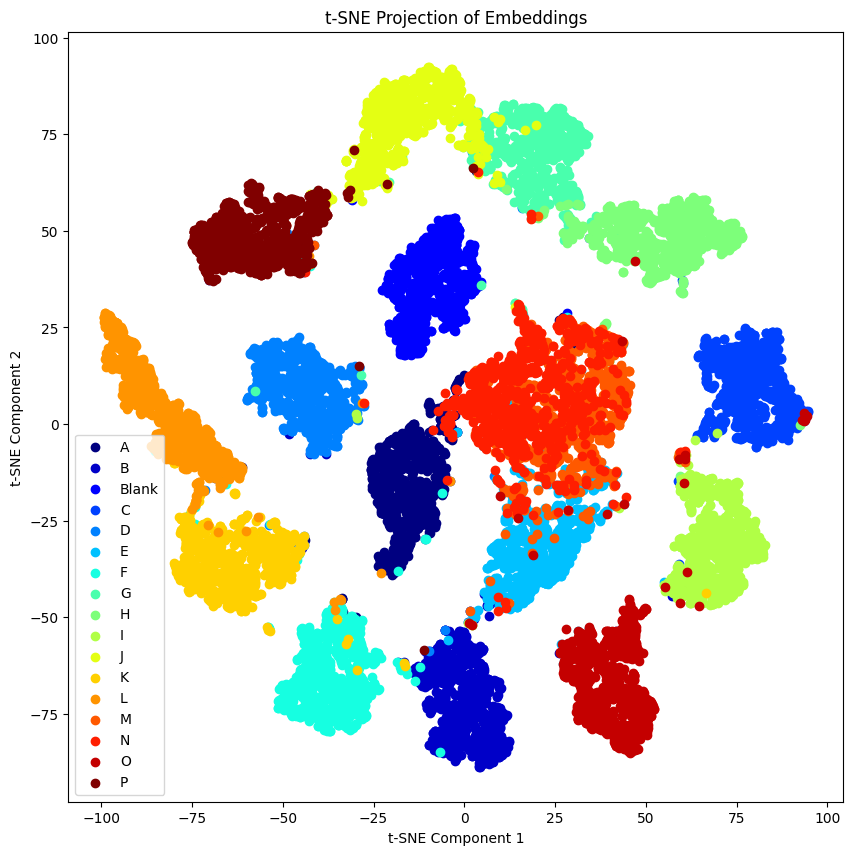

In [ ]:
# TSNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Project the embeddings to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42)
projected_embeddings = tsne.fit_transform(all_embeddings)

# Plotting
plt.figure(figsize=(10, 10))

# Unique labels for coloring
unique_labels = np.unique(all_labels)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    indices = np.where(all_labels == label)
    plt.scatter(projected_embeddings[indices, 0], projected_embeddings[indices, 1], label=label, color=colors[i])

plt.title("t-SNE Projection of Embeddings")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()


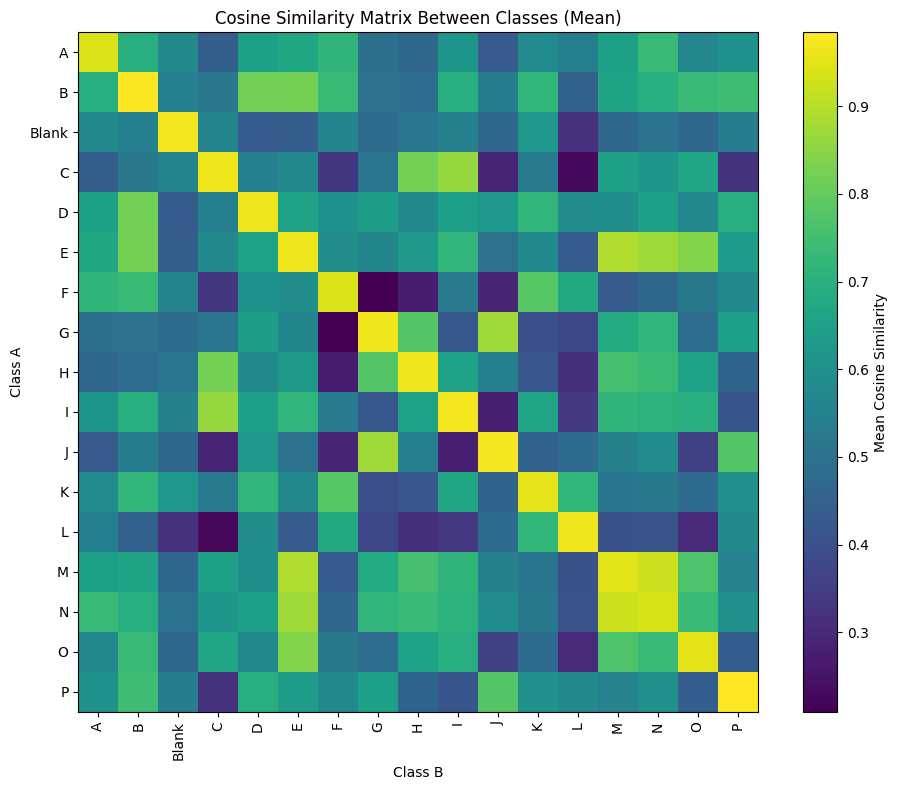

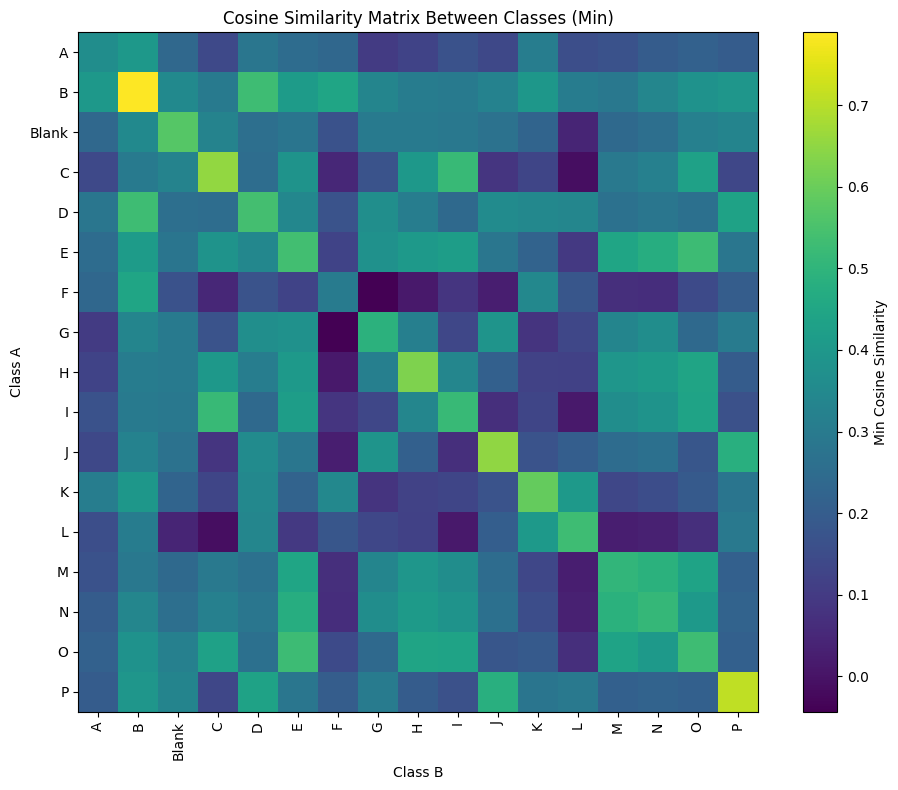

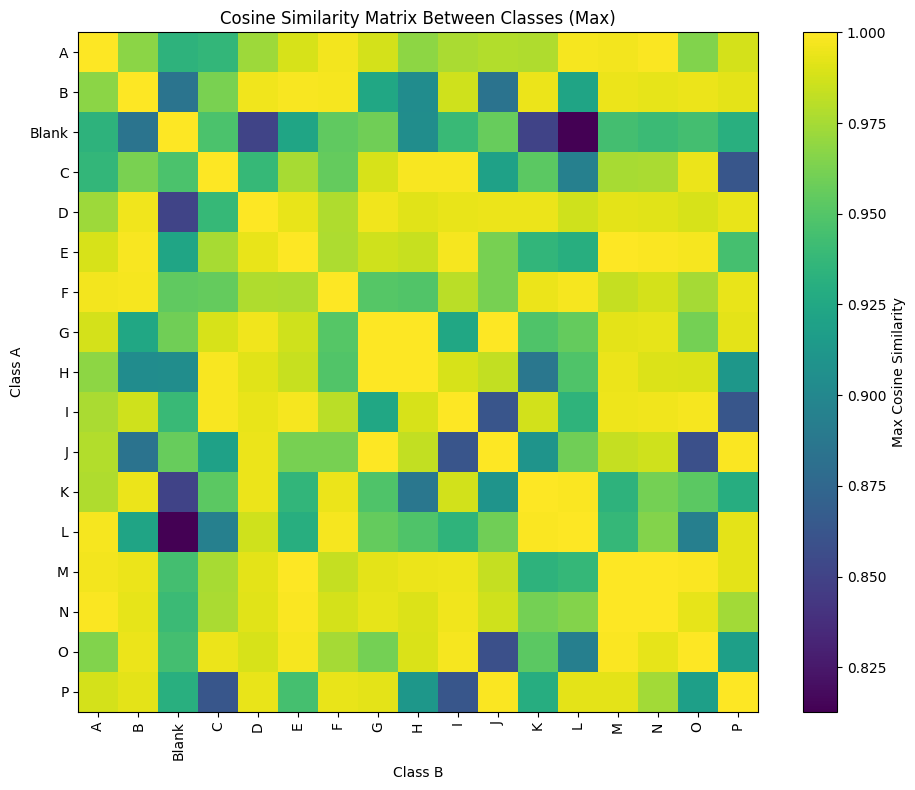

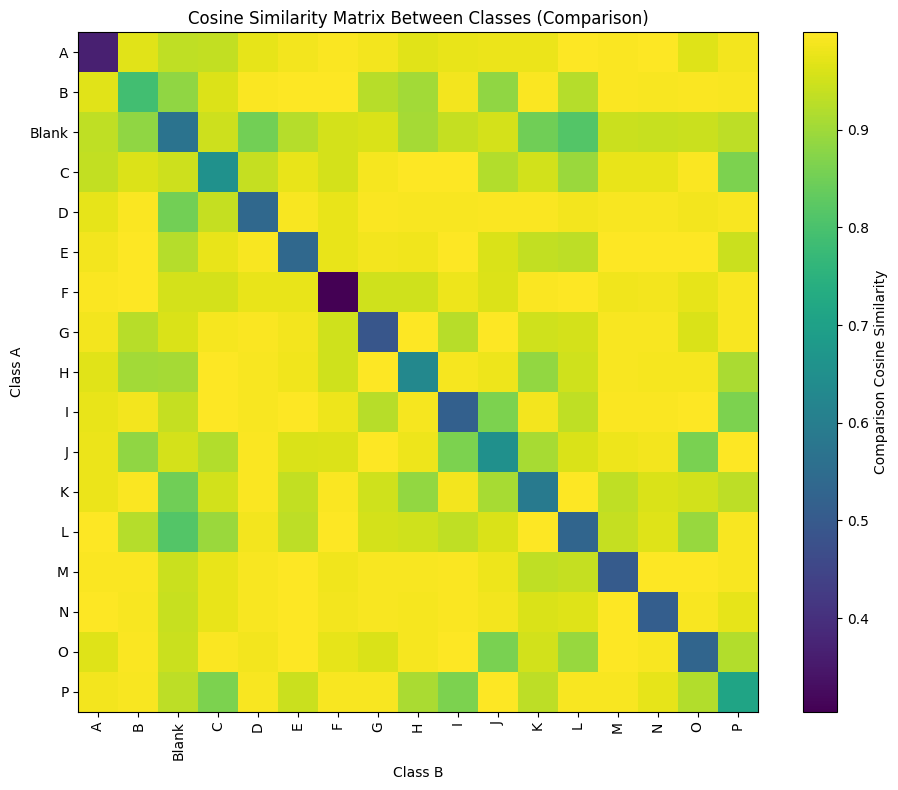

In [ ]:
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Extract unique class labels
unique_labels = np.unique(all_labels)
num_classes = len(unique_labels)

# Initialize the cosine similarity matrix
cosine_sim_matrix = np.zeros((4, num_classes, num_classes))

# Compute cosine similarities between every pair of classes
for i, lab_i in enumerate(unique_labels):
    for j, lab_j in enumerate(unique_labels):
        # Extract embeddings for class i and class j
        embeddings_class_i = np.array(all_embeddings[all_labels==lab_i])
        embeddings_class_j = np.array(all_embeddings[all_labels==lab_j])
        
        # Compute pairwise cosine similarities
        similarity = cosine_similarity(embeddings_class_i, embeddings_class_j)
        
        # Take the mean similarity as the representative similarity between class i and class j
        min_similarity = np.min(similarity)
        mean_similarity = np.mean(similarity)
        max_similarity = np.max(similarity)
        cosine_sim_matrix[:, i, j] = [mean_similarity, min_similarity, max_similarity, max_similarity]

cosine_sim_matrix[3, np.arange(num_classes), np.arange(num_classes)] = cosine_sim_matrix[1, np.arange(num_classes), np.arange(num_classes)]

# Plotting the similarity matrix as a heatmap
for mat, label in zip(cosine_sim_matrix, ["Mean", "Min", "Max", "Comparison"]):
    plt.figure(figsize=(10, 8))
    plt.imshow(mat, cmap='viridis', interpolation='nearest')
    plt.colorbar(label=f'{label} Cosine Similarity')
    plt.xticks(range(num_classes), unique_labels, rotation=90)
    plt.yticks(range(num_classes), unique_labels)
    plt.title(f'Cosine Similarity Matrix Between Classes ({label})')
    plt.xlabel('Class B')
    plt.ylabel('Class A')
    plt.tight_layout()
    plt.show()